# Preprocess Data
- Transforms and aligns all predictor and target series to a common quarterly grid
- Monthly series are stacked into per-quarter month columns (m1, m2, m3)
- Missing values are filled with column means. The resulting dataset and feature metadata are exported to csv

# Imports, Config & Utilities

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from config import (
    DATA_START, DATA_END,
    TEST_START, TEST_END,
    DATA_SERIES_PREPROCESSED_DIR, DATA_PATH,
    METADATA_SERIES_PATH, METADATA_FEATURES_PATH, TARGET, TEX_DATA_DIR
)

In [17]:
def get_var(df):
    '''
    returns the single non-time column name from df
    '''
    return [col for col in df.columns if col != 't'][0]

def transform(df, transformation):
    '''
    - applies the specified transformation to the variable column in df
    - supports: 'level change', 'ppt change', 'QoQ % change', 'MoM % change'
    - returns df with the transformed column
    - original column is dropped
    '''
    df = df.copy()
    var = get_var(df)
    if transformation in ('level change', 'ppt change'):
        df[f'{var} ({transformation})'] = df[var].diff()
        df = df.drop(columns=var)
    elif transformation in ('QoQ % change', 'MoM % change'):
        df[f'{var} ({transformation})'] = (df[var] / df[var].shift(1) - 1) * 100
        df = df.drop(columns=var)
    return df

def stack_monthly(df, freq):
    '''
    - for monthly series: pivots the three months of each quarter into separate
        columns (m1, m2, m3), returning a quarterly-indexed df
    - quarterly series are returned unchanged
    '''
    if freq != 'M':
        return df
    var = get_var(df)
    df = df.copy()
    df['q'] = df['t'].dt.to_period('Q')
    df['m'] = df.groupby('q').cumcount() + 1
    df = df.pivot_table(index='q', columns='m', values=var).reindex(columns=[1, 2, 3])
    df.columns = [f'{var} m{i}' for i in [1, 2, 3]]
    df['t'] = df.index.to_timestamp(how='start')
    return df.reset_index(drop=True)

def align_timeframe(df, start, end):
    '''
    - aligns df to a full quarterly grid from start to end (defined in config)
    - missing quarters are filled with NaN
    '''
    grid = pd.DataFrame({'t': pd.date_range(start=start, end=end, freq='QS')})
    return grid.merge(df, on='t', how='left')

def fillnas(df):
    '''
    fills NaN values in all non-time columns with the column mean
    '''
    df = df.copy()
    value_cols = [col for col in df.columns if col != 't']
    df[value_cols] = df[value_cols].fillna(df[value_cols].mean())
    return df

def process_series(s, start, end):
    '''
    - loads a preprocessed series csv
    - applies transformation and monthly stacking
    - aligns to the full quarterly grid
    - fills NaNs with column means
    '''
    df = pd.read_csv(DATA_SERIES_PREPROCESSED_DIR / s['file'])
    df['t'] = pd.to_datetime(df['t'])
    df = transform(df, s['transformation'])
    df = stack_monthly(df, s['freq'])
    df = align_timeframe(df, start, end)
    return fillnas(df)

# Dataset Construction

In [18]:
# load metadata of each series
metadata_series = (
    pd.read_csv(METADATA_SERIES_PATH, sep=';',
                usecols=['ID', 'Kept or Dropped', 'Publication lag', 'Frequency', 'Transformation'])
    .query("`Kept or Dropped` == 'Kept'")
    .drop(columns='Kept or Dropped')
    .where(pd.notnull, None)
)

metadata_series

,ID,Publication lag,Frequency,Transformation
0,CONST_TURNOVER,2.0,M,MoM % change
1,PERMITS,2.0,M,level change
4,MFG_ORDERS,2.0,M,MoM % change
5,IND_PROD,2.0,M,MoM % change
6,CAP_UTIL,1.0,Q,ppt change
7,MFG_TURNOVER,2.0,M,MoM % change
12,RETAIL_TURNOVER,2.0,M,MoM % change
13,CONSUMPTION,1.0,Q,QoQ % change
14,DISP_INC,1.0,Q,QoQ % change
15,EMPLOYMENT_ESA,2.0,M,level change


In [19]:
# apply preprocessing to each series and merge into one dataset
dataset = pd.DataFrame({'t': pd.date_range(start=DATA_START, end=DATA_END, freq='QS')})
for _, row in metadata_series.iterrows():
    s = {'file': f"{row['ID']}.csv", 'transformation': row['Transformation'], 'freq': row['Frequency']}
    dataset = dataset.merge(process_series(s, DATA_START, DATA_END), on='t', how='left')

dataset.to_csv(DATA_PATH, index=False)

dataset.head()

,t,CONST_TURNOVER (MoM % change) m1,CONST_TURNOVER (MoM % change) m2,CONST_TURNOVER (MoM % change) m3,PERMITS (level change) m1,PERMITS (level change) m2,PERMITS (level change) m3,MFG_ORDERS (MoM % change) m1,MFG_ORDERS (MoM % change) m2,MFG_ORDERS (MoM % change) m3,...,HICP (MoM % change) m1,HICP (MoM % change) m2,HICP (MoM % change) m3,CPI_CORE (MoM % change) m1,CPI_CORE (MoM % change) m2,CPI_CORE (MoM % change) m3,PPI (MoM % change) m1,PPI (MoM % change) m2,PPI (MoM % change) m3,GNI (QoQ % change)
0,1991-01-01,0.626492,-0.110163,0.999406,-2.053917,-0.738447,0.575771,-0.584936,-4.230118,1.766784,...,0.198133,0.133647,0.146786,0.107957,0.151499,0.133355,0.170346,0.152439,-0.152207,0.799226
1,1991-04-01,0.626492,-0.110163,0.999406,-2.053917,-0.738447,0.575771,-2.777778,-0.535714,1.615799,...,0.198133,0.133647,0.146786,0.107957,0.151499,0.133355,0.914634,0.000000,0.151057,2.066229
2,1991-07-01,0.626492,-0.110163,0.999406,-2.053917,-0.738447,0.575771,-2.650177,5.626134,-4.982818,...,0.198133,0.133647,0.146786,0.107957,0.151499,0.133355,0.754148,0.149701,0.298954,0.509718
3,1991-10-01,0.626492,-0.110163,0.999406,-2.053917,-0.738447,0.575771,1.989150,1.773050,1.045296,...,0.198133,0.133647,0.146786,0.107957,0.151499,0.133355,-0.149031,0.149254,0.000000,2.037220
4,1992-01-01,0.626492,-0.110163,0.999406,-2.053917,-0.738447,0.575771,-0.862069,0.173913,-0.694444,...,0.198133,0.133647,0.146786,0.107957,0.151499,0.133355,-0.596125,0.449775,0.298507,4.054882


In [20]:
# construct feature-level metadata (one row per column in the dataset)
rows = []
for _, row in metadata_series.iterrows():
    name = row['ID'] if pd.isna(row['Transformation']) else f"{row['ID']} ({row['Transformation']})"
    if row['Frequency'] == 'M':
        rows.extend({'Name': f"{name} m{m}", **row} for m in [1, 2, 3])
    else:
        rows.append({'Name': name, **row})

metadata_features = pd.DataFrame(rows).drop(columns=['ID', 'Transformation'])

metadata_features['Applied NaNs'] = 0
for idx, row in metadata_features.iterrows():
    if row['Frequency'] == 'Q':
        metadata_features.at[idx, 'Applied NaNs'] = row['Publication lag']
    elif row['Publication lag'] >= 1 and 'm3' in row['Name']:
        metadata_features.at[idx, 'Applied NaNs'] = 1
    elif row['Publication lag'] >= 2 and ('m2' in row['Name'] or 'm3' in row['Name']):
        metadata_features.at[idx, 'Applied NaNs'] = 1
    elif row['Publication lag'] >= 3 and ('m1' in row['Name'] or 'm2' in row['Name'] or 'm3' in row['Name']):
        metadata_features.at[idx, 'Applied NaNs'] = 1

metadata_features.to_csv(METADATA_FEATURES_PATH, index=False)

metadata_features.head()

,Name,Publication lag,Frequency,Applied NaNs
0,CONST_TURNOVER (MoM % change) m1,2.0,M,0
1,CONST_TURNOVER (MoM % change) m2,2.0,M,1
2,CONST_TURNOVER (MoM % change) m3,2.0,M,1
3,PERMITS (level change) m1,2.0,M,0
4,PERMITS (level change) m2,2.0,M,1


# Export

In [ ]:
# export for line chart in resutls chapter
df = dataset[['t', TARGET]]
df["year"] = df["t"].dt.year + (df["t"].dt.quarter - 1) / 4
is_test = (df["t"] >= TEST_START) & (df["t"] <= TEST_END)

test_idx = df.index[is_test]
excl_idx = test_idx[:5]
rest_idx = test_idx[5:]

is_train = df["t"] < TEST_START
is_excl = df.index.isin(excl_idx)
is_rest = df.index.isin(rest_idx)

gdp = df[TARGET]

df["gdp_train"] = np.where(is_train, gdp, np.nan)
df["gdp_test_excl"] = np.where(is_excl,  gdp, np.nan)
df["gdp_test"] = np.where(is_rest,  gdp, np.nan)

last_train_idx = df.index[is_train][-1]
df.loc[last_train_idx, "gdp_test_excl"] = gdp.loc[last_train_idx]

last_excl_idx = excl_idx[-1]
df.loc[last_excl_idx, "gdp_test"] = gdp.loc[last_excl_idx]

df[["year", "gdp_train", "gdp_test_excl", "gdp_test"]].to_csv(
    TEX_DATA_DIR / "gdp_split.csv", index=False, na_rep="nan"
)

# Validation Plots

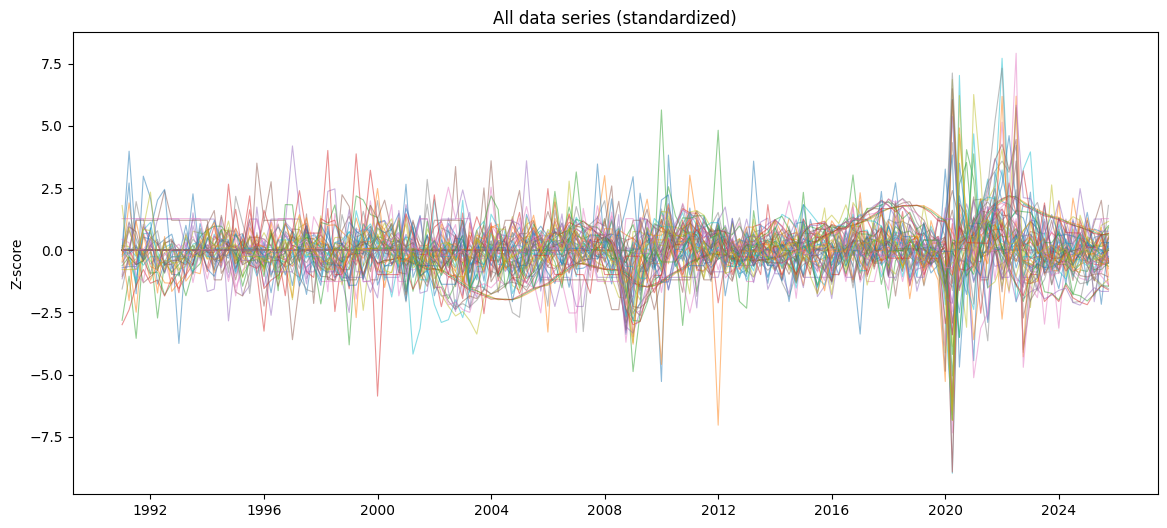

In [22]:
# all series on one panel, standardized
variables = [col for col in dataset.columns if col != 't']
df_norm = dataset[variables].apply(lambda x: (x - x.mean()) / x.std())

fig, ax = plt.subplots(figsize=(14, 6))
for col in variables:
    ax.plot(dataset['t'], df_norm[col], linewidth=0.8, alpha=0.5)
ax.set_ylabel('Z-score')
ax.set_title('All data series (standardized)')
plt.show()

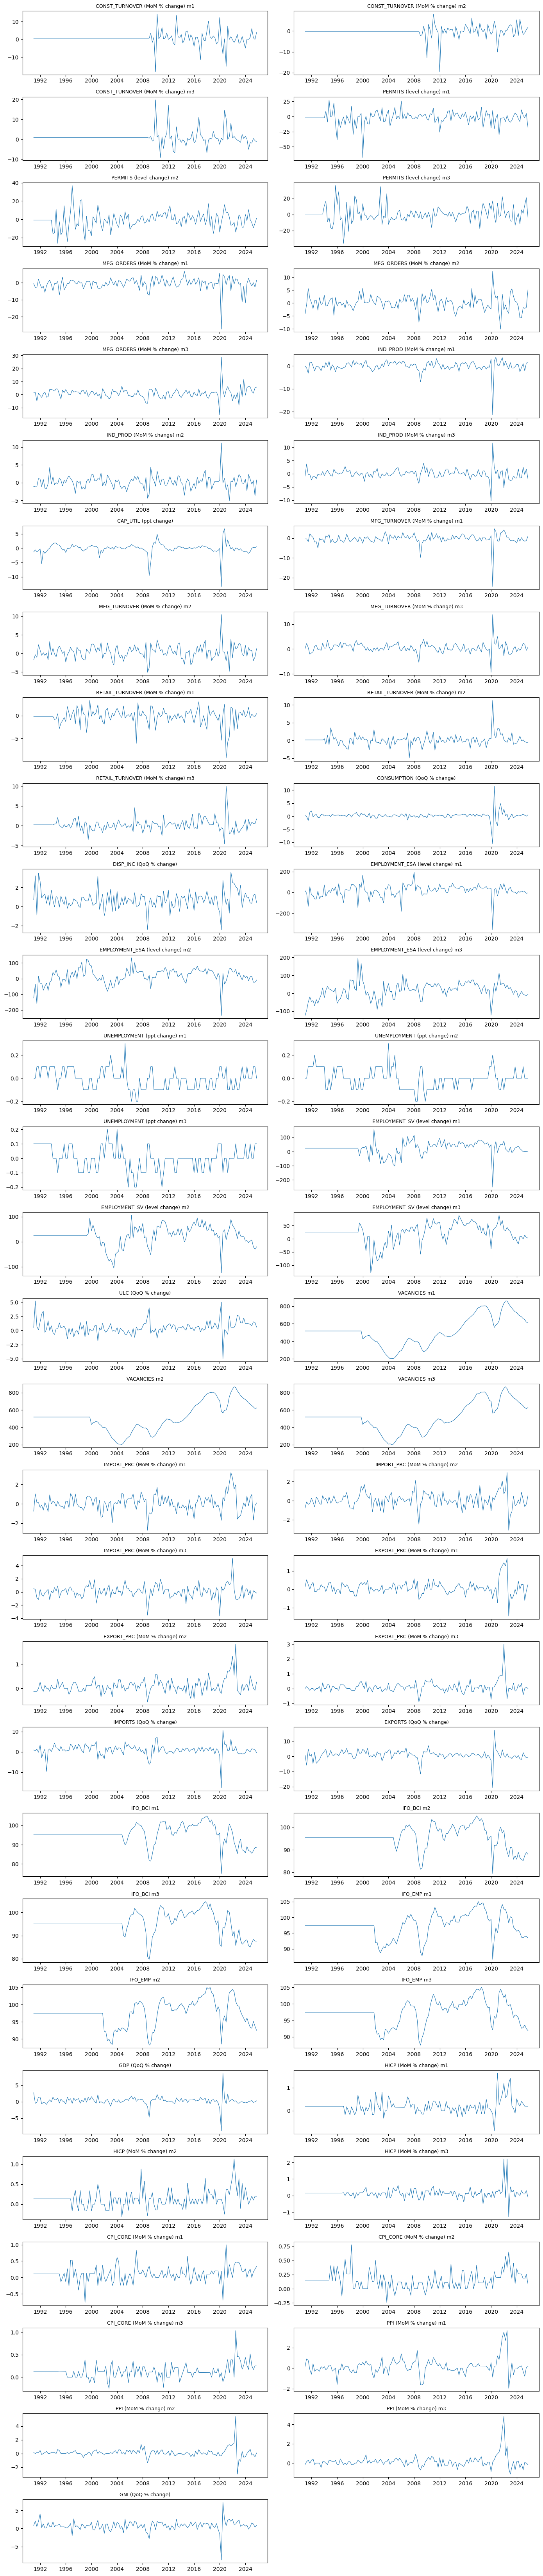

In [23]:
# one panel per series
ncols = 2
nrows = (len(variables) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 2.2 * nrows))
axes = axes.flatten()
for i, col in enumerate(variables):
    axes[i].plot(dataset['t'], dataset[col], linewidth=0.8)
    axes[i].set_title(col, fontsize=9)
for j in range(len(variables), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()